In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

In [2]:
def f(x, y):
    return -2 * y * np.cos(x)

def exact(x):
    return np.exp(-2 * np.sin(x))

def euler(h, x_end=10 * np.pi):
    xs = [0.0]
    ys = [1.0]
    x = 0.0
    y = 1.0
    while x < x_end - 1e-12:
        h_step = min(h, x_end - x)
        y = y + h_step * f(x, y)
        x = x + h_step
        xs.append(x)
        ys.append(y)
    return np.array(xs), np.array(ys)

In [3]:
h_values = [0.01, 0.05, 0.15, 0.20, 0.25,
            0.30,0.35, 0.40, 0.45, 0.50,
            0.55, 0.60, 0.65, 0.70, 0.75, 
            0.80, 0.85, 0.90, 0.95, 1.00]

X_END   = 10 * np.pi
TARGET  = 15.0          

results = {}
for h in h_values:
    xs, ys = euler(h, X_END)
    results[h] = (xs, ys)

avg_errors   = []
local_errors = []

for h in h_values:
    xs, ys = results[h]
    y_exact = exact(xs)

    
    avg_err = np.mean(np.abs(ys - y_exact))
    avg_errors.append(avg_err)

    
    idx = np.argmin(np.abs(xs - TARGET))
    local_err = abs(ys[idx] - exact(xs[idx]))
    local_errors.append(local_err)



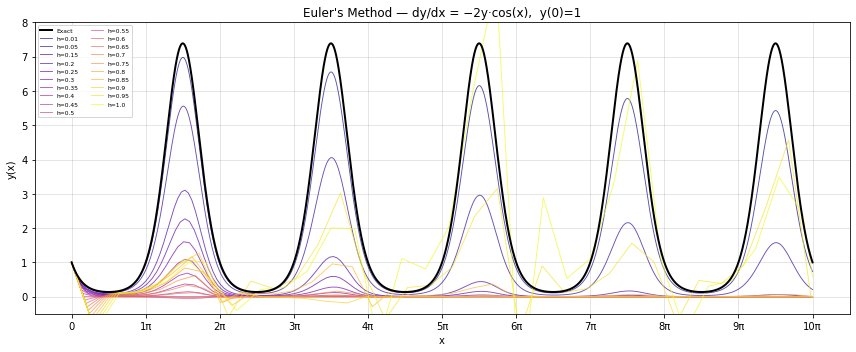

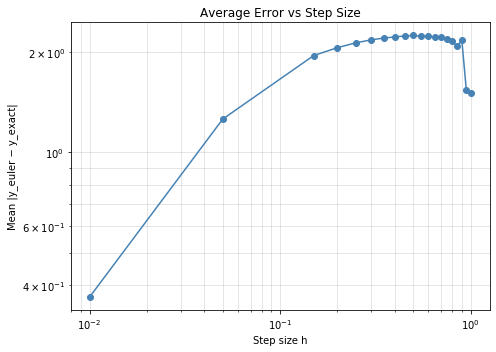

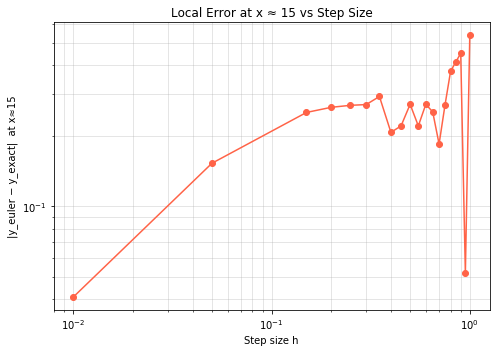

In [4]:



colors = plt.cm.plasma(np.linspace(0, 1, len(h_values)))

fig, ax = plt.subplots(figsize=(12, 5))
x_dense = np.linspace(0, 10 * np.pi, 5000)
ax.plot(x_dense, exact(x_dense), 'k-', lw=2, label='Exact', zorder=10)
for i, h in enumerate(h_values):
    xs, ys = results[h]
    ax.plot(xs, ys, color=colors[i], lw=0.9, alpha=0.7, label=f'h={h}')
ax.set_xlabel('x')
ax.set_ylabel('y(x)')
ax.set_title("Euler's Method — dy/dx = −2y·cos(x),  y(0)=1")
ax.set_xticks([k * np.pi for k in range(11)])
ax.set_xticklabels([f'{k}π' if k else '0' for k in range(11)])
ax.set_ylim(-0.5, 8)
ax.legend(fontsize=6, ncol=2, loc='upper left')
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()
 
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(h_values, avg_errors, 'o-', color='steelblue')
ax.set_xlabel('Step size h')
ax.set_ylabel('Mean |y_euler − y_exact|')
ax.set_title('Average Error vs Step Size')
ax.set_xscale('log')
ax.set_yscale('log')
ax.grid(True, which='both', alpha=0.4)
plt.tight_layout()
plt.show()
 
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(h_values, local_errors, 'o-', color='tomato')
ax.set_xlabel('Step size h')
ax.set_ylabel('|y_euler − y_exact|  at x≈15')
ax.set_title('Local Error at x ≈ 15 vs Step Size')
ax.set_xscale('log')
ax.set_yscale('log')
ax.grid(True, which='both', alpha=0.4)
plt.tight_layout()
plt.show()